In [1]:
# Put this in a cell BEFORE importing paddleocr / creating PaddleOCR
import os
os.environ["FLAGS_use_mkldnn"] = "0"     # disable oneDNN (MKLDNN)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # sometimes helps on Windows envs
os.environ["FLAGS_use_new_executor"] = "0"

In [3]:
# Cell 2 — Imports + paths
import os, json
from pathlib import Path
from typing import List, Dict, Any, Tuple

import cv2
from PIL import Image, ImageDraw

INPUT_PNG_DIR = Path("./data/jap_imgs")          # <-- change if needed
OUT_JSON_DIR  = Path("./outputs/ocr_json_jap")
OUT_VIS_DIR   = Path("./outputs/ocr_vis_jap")

OUT_JSON_DIR.mkdir(parents=True, exist_ok=True)
OUT_VIS_DIR.mkdir(parents=True, exist_ok=True)

png_files = sorted(INPUT_PNG_DIR.glob("*.png"))
print("Found PNGs:", len(png_files))
if png_files:
    print("Example:", png_files[0])

Found PNGs: 6
Example: data\jap_imgs\pg_1.png


In [33]:
import torch
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
from paddleocr import TextDetection
model = TextDetection(
    model_name="PP-OCRv5_server_det",
    device = "gpu",
    )

C:\Users\abcdj\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\abcdj\.paddlex\official_models\PP-OCRv5_server_det`.


AttributeError: 'TextDetection' object has no attribute 'to'

In [5]:
temp = png_files[1]

In [7]:
output = model.predict(str(temp), batch_size=1)

In [8]:
for res in output:
    res.print()

{'res': {'input_path': 'data\\jap_imgs\\pg_2.png', 'page_index': None, 'dt_polys': array([[[  17, 1546],
        ...,
        [  17, 1599]],

       ...,

       [[ 467,   32],
        ...,
        [ 467,  172]]], shape=(41, 4, 2), dtype=int16), 'dt_scores': [0.8496326885314193, 0.7948792359378563, 0.8373084696644219, 0.7998542351892308, 0.717147208865544, 0.745379385430939, 0.6985167740788187, 0.7952162239452204, 0.8640405484243001, 0.8256710344713962, 0.8519891265141536, 0.7120950212589436, 0.8194311306167095, 0.8333559033785836, 0.9313648342013081, 0.6181839614344353, 0.6190426215151393, 0.762373079630326, 0.8931301284489799, 0.8260327161759393, 0.7438958462611702, 0.860138350216, 0.7768295670348498, 0.8430414368204131, 0.8622673111709042, 0.8723421688764714, 0.9312113178102897, 0.8841026723437988, 0.7532379501857437, 0.6217182715288212, 0.9079251831286497, 0.683489877428136, 0.6230613320600241, 0.7961792203649464, 0.8978256705763653, 0.9183767252338207, 0.8179258907415194, 0.902449

In [12]:
output[0].keys()

dict_keys(['input_path', 'page_index', 'input_img', 'dt_polys', 'dt_scores'])

In [18]:
print(output[0]['dt_polys'][0])

[[  17 1546]
 ...
 [  17 1599]]


In [19]:
polys = output[0]['dt_polys']

In [20]:
img = cv2.imread(str(temp))

In [21]:
img

array([[[ 51, ...,  51],
        ...,
        [255, ..., 255]],

       ...,

       [[ 51, ...,  51],
        ...,
        [255, ..., 255]]], shape=(1599, 1010, 3), dtype=uint8)

In [22]:
import numpy as np

In [23]:
vis = np.array(img)

In [28]:
display(img)

array([[[ 51, ...,  51],
        ...,
        [255, ..., 255]],

       ...,

       [[ 51, ...,  51],
        ...,
        [255, ..., 255]]], shape=(1599, 1010, 3), dtype=uint8)

In [25]:
display(vis)

array([[[ 51, ...,  51],
        ...,
        [255, ..., 255]],

       ...,

       [[ 51, ...,  51],
        ...,
        [255, ..., 255]]], shape=(1599, 1010, 3), dtype=uint8)

In [29]:
for it in polys:
    pts = np.array(it, dtype=np.int32)
    cv2.polylines(vis, [pts], True, (0, 255, 0), 2)

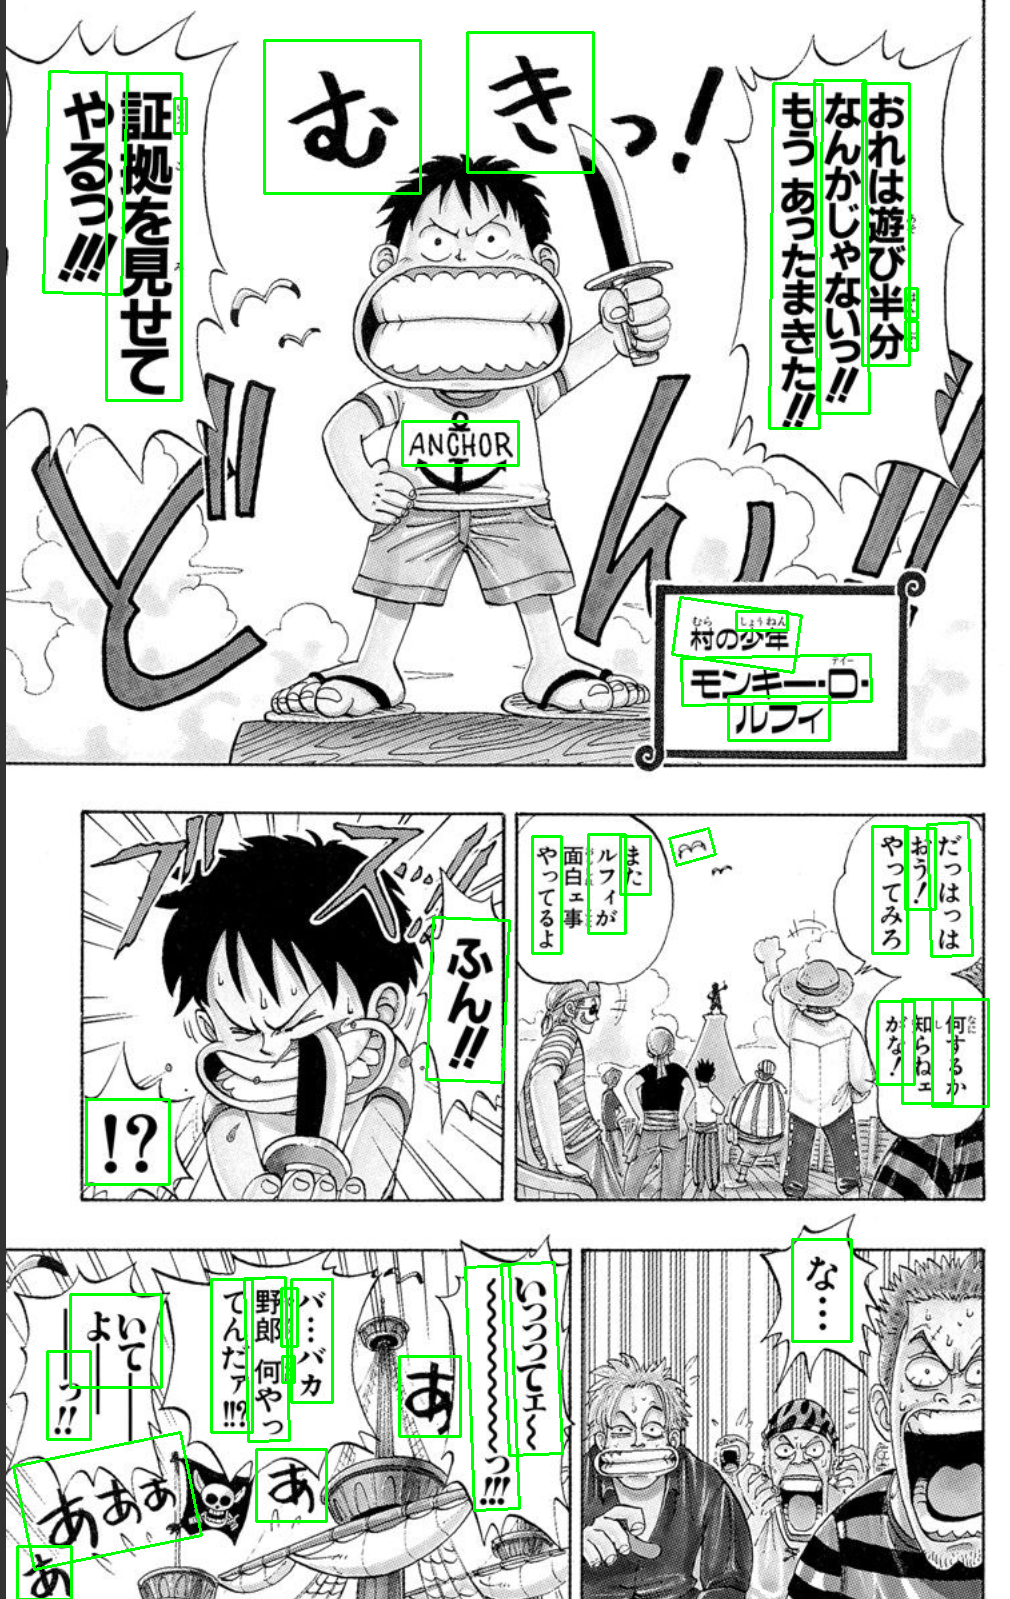

In [31]:
Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))